In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
if not (ROOT / "generation").exists() and (ROOT.parent / "generation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.kernelExperiments import (
    array_response_core_v2,
    build_shared_az_el_grid,
    clear_torch_memory,
    az_el_cuts,
    compare_response_cores,
    compare_chunked_triton_batch_timings,
    compare_response_core_timings,
    compare_response_tensors,
    dense_array_response,
    dense_response_grid,
    load_evolution_chunk_size,
    make_benchmark_batch,
    plot_az_el_cuts,
    plot_outputs,
    plot_response_comparison,
    plot_response_grid,
)
from scripts.arraySpec import ArraySpec
from scripts.batchFactory import generateBatch
from simulation.arraySim import arrayResponseSample


In [2]:
dtype = torch.float32
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Keep this notebook on the single-sample path. The helpers default to sample_id=0.
generator = torch.Generator(device=device).manual_seed(7)
spec = ArraySpec(allowedElementCount=(50000,), allowedAspectRatio=(1.0,))
batch = generateBatch(
    spec,
    batchSize=10,
    device=device,
    dtype=dtype,
    elementCount=50000,
    aspectRatio=1.0,
    weightsType="uniform",
    generator=generator,
)

batch.batchSize, batch.N, batch.device


(10, 50176, device(type='cuda', index=0))

In [3]:
# Direct dense response at any broadcastable az/el shape. Angles are radians.
azimuth = torch.linspace(-torch.pi, torch.pi, 361, device=device, dtype=dtype)
elevation = torch.zeros_like(azimuth)
response_db = dense_array_response(
    batch,
    azimuth,
    elevation,
    dB=True,
    normalize=True,
)

response_db.shape, float(response_db.max().detach().cpu())


(torch.Size([361]), 1.0)

In [4]:
# Quick parity check against the current chunked sample implementation.
az_small = torch.linspace(-0.7, 0.9, 17, device=device, dtype=dtype)
el_small = torch.linspace(-0.4, 0.5, 13, device=device, dtype=dtype)
az_grid, el_grid = torch.meshgrid(az_small, el_small, indexing="ij")

dense = dense_array_response(batch, az_grid, el_grid, dB=True, normalize=True)
chunked = arrayResponseSample(batch, 0, az_grid, el_grid, dB=True, normalize=True)
parity_atol = 5e-3 if device.type == "cuda" else 1e-5
parity_rtol = 1e-4 if device.type == "cuda" else 1e-5
parity = compare_response_tensors(dense, chunked, atol=parity_atol, rtol=parity_rtol)
torch.testing.assert_close(dense, chunked, rtol=parity_rtol, atol=parity_atol)
parity


{'shape_match': True,
 'reference_shape': (17, 13),
 'candidate_shape': (17, 13),
 'allclose': True,
 'atol': 0.005,
 'rtol': 0.0001,
 'max_abs': 0.0027008056640625,
 'mean_abs': 0.00010836825822480023,
 'rmse': 0.0002647402579896152,
 'max_rel': 2.7543042961042374e-05,
 'mean_rel': 1.5234961665555602e-06}

In [5]:
# V2 uses the Triton-backed implementation from experiments.kernelExperiments.
# Edit this wrapper if you want to try a different candidate while keeping the
# comparison cells below unchanged.

def triton_array_response(
    batch,
    azimuth,
    elevation,
    *,
    sample_id=0,
    dB=False,
    normalize=False,
):
    return array_response_core_v2(
        batch,
        azimuth,
        elevation,
        sample_id=sample_id,
        dB=dB,
        normalize=normalize,
    )


In [6]:
# Candidate-vs-reference check.
az_cmp = torch.linspace(-0.7, 0.9, 120, device=device, dtype=dtype)
el_cmp = torch.linspace(-0.4, 0.5, 100, device=device, dtype=dtype)
az_cmp_grid, el_cmp_grid = torch.meshgrid(az_cmp, el_cmp, indexing="ij")

comparison = compare_response_cores(
    batch,
    az_cmp_grid,
    el_cmp_grid,
    candidate_fn=triton_array_response,
    dB=True,
    normalize=True,
    atol=2e-4 if device.type == "cuda" else 1e-5,
    rtol=2e-4 if device.type == "cuda" else 1e-4,
)
comparison["metrics"]


{'shape_match': True,
 'reference_shape': (120, 100),
 'candidate_shape': (120, 100),
 'allclose': False,
 'atol': 0.0002,
 'rtol': 0.0002,
 'max_abs': 0.05419158935546875,
 'mean_abs': 0.0005629104562103748,
 'rmse': 0.002051928546279669,
 'max_rel': 0.0005658544250763953,
 'mean_rel': 6.2212907323555555e-06}

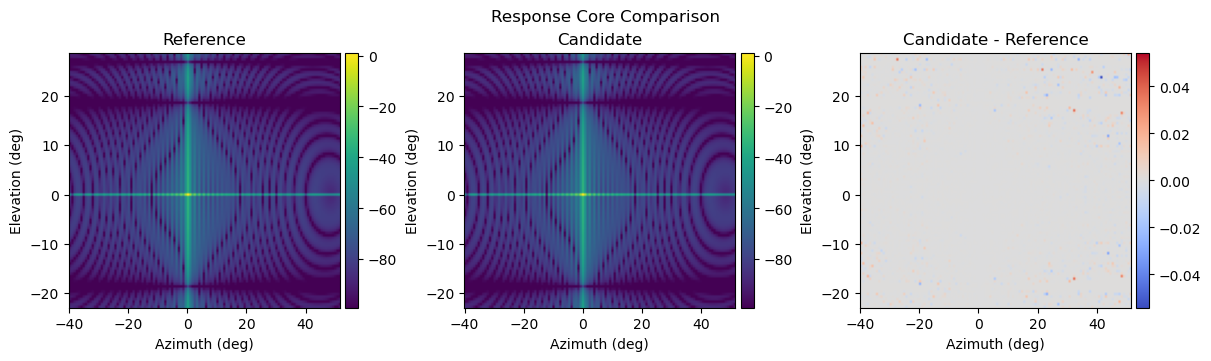

In [7]:
comparison_grid = {
    "azimuth_axis": az_cmp,
    "elevation_axis": el_cmp,
    "response": comparison["reference"],
}
fig = plot_response_comparison(comparison, comparison_grid)
plt.show()


In [8]:
# Simple timing comparison on the same grid used above.
# Warmup includes Triton compilation, so measured repeats should reflect steady-state calls.
timing = compare_response_core_timings(
    batch,
    az_cmp_grid,
    el_cmp_grid,
    candidate_fn=triton_array_response,
    dB=True,
    normalize=True,
    warmup=3,
    repeat=20,
    atol=2e-4 if device.type == "cuda" else 1e-5,
    rtol=2e-4 if device.type == "cuda" else 1e-4,
)

{
    "dense_mean_ms": timing["reference"]["mean_ms"],
    "dense_min_ms": timing["reference"]["min_ms"],
    "v2_mean_ms": timing["candidate"]["mean_ms"],
    "v2_min_ms": timing["candidate"]["min_ms"],
    "speedup_mean": timing["speedup"],
    "allclose": timing["metrics"]["allclose"],
    "max_abs": timing["metrics"].get("max_abs"),
}


{'dense_mean_ms': 216.2536540999838,
 'dense_min_ms': 215.1570170000241,
 'v2_mean_ms': 16.28653239998812,
 'v2_min_ms': 16.19879099996524,
 'speedup_mean': 13.278066121683555,
 'allclose': False,
 'max_abs': 0.05419158935546875}

In [ ]:
# Realistic timing comparison: production chunked shared-grid kernel vs Triton V2.
# The chunked path uses configs/evolution/evo_v2_reference.yaml wideResponseChunkSize.
# This is intentionally opt-in. The full size is roughly 50 * 25k * 256 * 256
# element-point accumulations per response pass.
RUN_REALISTIC_BENCHMARK = True

if RUN_REALISTIC_BENCHMARK:
    if device.type != "cuda":
        raise RuntimeError("The realistic benchmark is intended for CUDA.")

    for name in [
        "benchmark_batch",
        "bench_az_grid",
        "bench_el_grid",
        "realistic_timing",
        "realistic_summary",
    ]:
        if name in globals():
            del globals()[name]
    clear_torch_memory(device)

    evo_v2_chunk_size = load_evolution_chunk_size(
        ROOT / "configs" / "evolution" / "evo_v2_reference.yaml",
        key="wideResponseChunkSize",
    )
    benchmark_batch = make_benchmark_batch(
        batch_size=20,
        element_count=25_000,
        device=device,
        dtype=dtype,
        random_weights=True,
        seed=123,
    )
    _, _, bench_az_grid, bench_el_grid = build_shared_az_el_grid(
        device=device,
        dtype=dtype,
        azimuth_points=256,
        elevation_points=256,
    )
    clear_torch_memory(device)

    realistic_timing = compare_chunked_triton_batch_timings(
        benchmark_batch,
        bench_az_grid,
        bench_el_grid,
        chunk_size=evo_v2_chunk_size,
        dB=False,
        normalize=False,
        warmup=1,
        repeat=3,
        compare_outputs=True,
        clear_memory_between=True,
        atol=5e-3,
        rtol=1e-4,
    )
    clear_torch_memory(device)

    realistic_summary = {
        "evo_v2_chunk_size": evo_v2_chunk_size,
        "config": realistic_timing["config"],
        "chunked_mean_ms": realistic_timing["chunked"]["mean_ms"],
        "chunked_min_ms": realistic_timing["chunked"]["min_ms"],
        "triton_mean_ms": realistic_timing["triton"]["mean_ms"],
        "triton_min_ms": realistic_timing["triton"]["min_ms"],
        "speedup_mean": realistic_timing["speedup"],
        "allclose": realistic_timing["metrics"]["allclose"],
        "max_abs": realistic_timing["metrics"].get("max_abs"),
        "rmse": realistic_timing["metrics"].get("rmse"),
    }
    display(realistic_summary)
else:
    realistic_summary = "Set RUN_REALISTIC_BENCHMARK = True to run the comparison."
    display(realistic_summary)


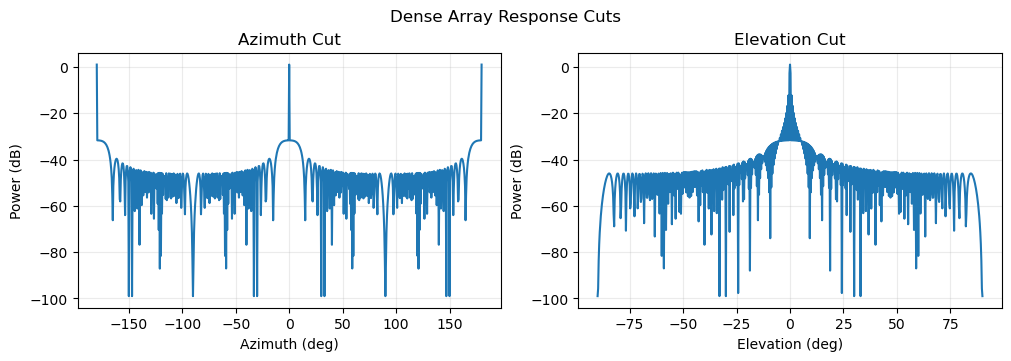

In [10]:
cuts = az_el_cuts(
    batch,
    points=721,
    fixed_azimuth=0.0,
    fixed_elevation=0.0,
    dB=True,
    normalize=True,
)
fig = plot_az_el_cuts(cuts)
plt.show()


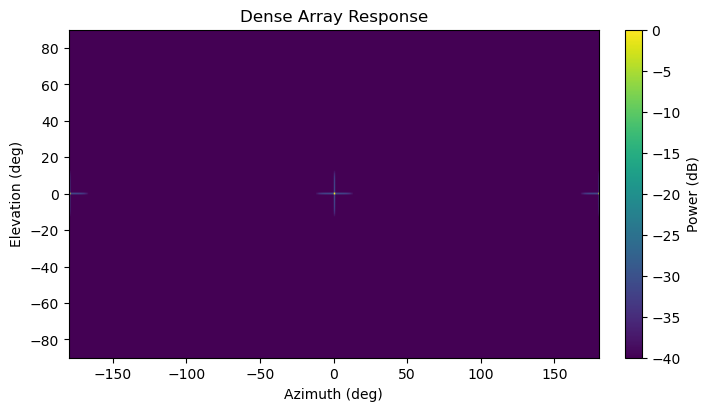

In [11]:
grid = dense_response_grid(
    batch,
    azimuth_points=361,
    elevation_points=181,
    dB=True,
    normalize=True,
)
fig = plot_response_grid(grid, vmin=-40.0, vmax=0.0)
plt.show()


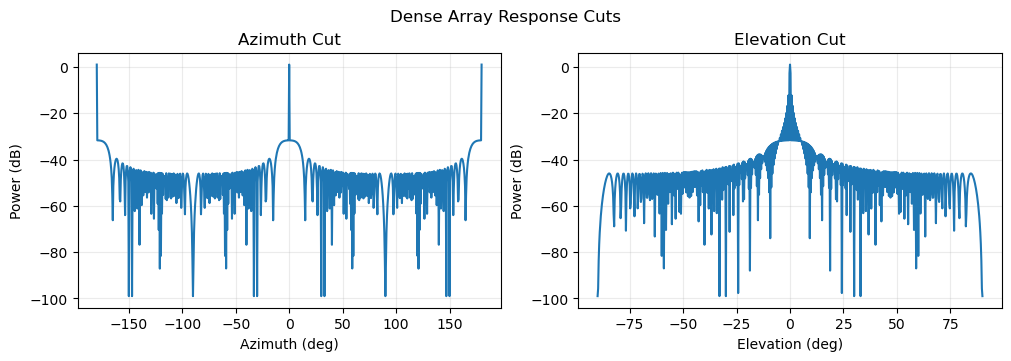

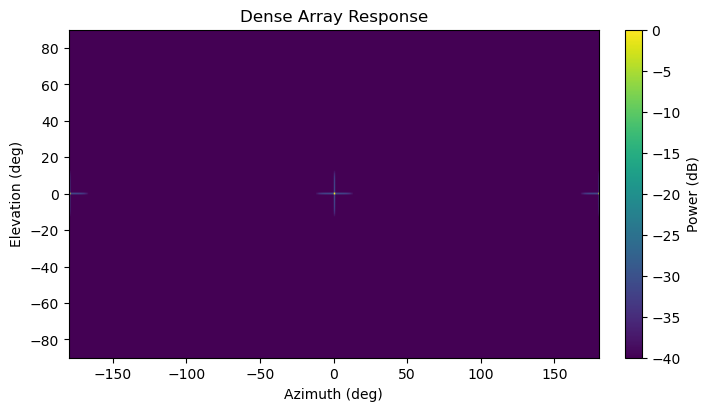

dict_keys(['cuts', 'grid', 'cut_figure', 'grid_figure'])

In [12]:
# Convenience wrapper when you want both figures and raw outputs in one object.
outputs = plot_outputs(
    batch,
    cut_points=721,
    azimuth_points=361,
    elevation_points=181,
)
plt.show()

outputs.keys()
